Number of records: 1500
Number of columns: 6

Target Labels / Classes:

['neutral' 'positive' 'negative']

Class Distribution:

sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64

Sample Customer Messages:

0    I need information about the payment process. ...
1        I need information about the payment process.
2    The refund process was fast and convenient. I ...
3    My refund is still pending and this experience...
4     Please tell me how to update my account details.
Name: customer_message, dtype: object

Average Text Length:

12.722666666666667

Text Length Statistics:

count    1500.000000
mean       12.722667
std         3.691455
min         7.000000
25%        10.000000
50%        12.000000
75%        15.000000
max        26.000000
Name: text_length, dtype: float64


sentiment_label
neutral     34.933333
negative    33.133333
positive    31.933333
Name: proportion, dtype: float64


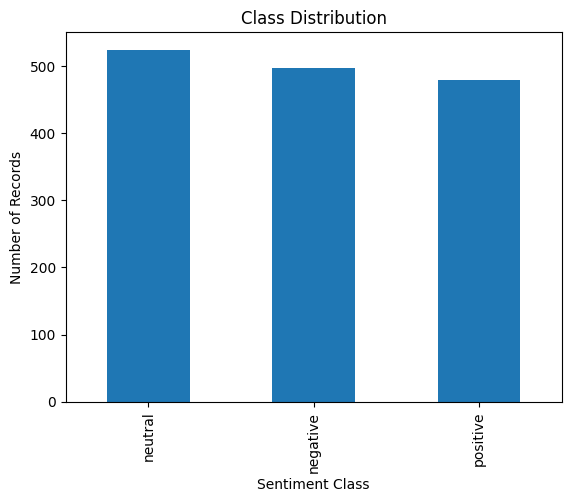

In [7]:
# Task 1: Dataset Understanding

import pandas as pd
import matplotlib.pyplot as plt

import re
import nltk

from nltk.corpus import stopwords
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


df = pd.read_csv("customer_support_text_classification.csv")

df.head()

# Number of Records
print("Number of records:", df.shape[0])
print("Number of columns:", df.shape[1])

# Target labels/classes
print("\nTarget Labels / Classes:\n")
print(df['sentiment_label'].unique())

# Class distribution
print("\nClass Distribution:\n")
print(df['sentiment_label'].value_counts())

# Sample text records
print("\nSample Customer Messages:\n")
print(df['customer_message'].head(5))

# Calculate text length
df['text_length'] = df['customer_message'].apply(
    lambda x: len(str(x).split())
)

# Average text length
print("\nAverage Text Length:\n")
print(df['text_length'].mean())

# Basic statistics of text length
print("\nText Length Statistics:\n")
print(df['text_length'].describe())

# Class distribution percentage
print("\n")
class_percentage = df["sentiment_label"].value_counts(normalize=True) * 100
print(class_percentage)

# Plot class distribution

df["sentiment_label"].value_counts().plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Sentiment Class")
plt.ylabel("Number of Records")

plt.show()

In [9]:
# Task 2: Text Preprocessing

# Download stopwords
nltk.download("stopwords")

# Load dataset
df = pd.read_csv("customer_support_text_classification.csv")

# Stopwords
stop_words = set(stopwords.words("english"))

# Function to clean text
def clean_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove numbers and special characters
    text = re.sub(r"[^a-z\s]", "", text)

    # Tokenization
    words = text.split()

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    # Join cleaned words
    cleaned_text = " ".join(words)

    return cleaned_text

# Apply cleaning
df["cleaned_message"] = df["customer_message"].apply(clean_text)

# Tokenization
max_words = 5000

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(df["cleaned_message"])

sequences = tokenizer.texts_to_sequences(df["cleaned_message"])

# Padding
max_length = 30

X = pad_sequences(
    sequences,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

# Encode target labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df["sentiment_label"])

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Display results
print("\n Original Text:\n")
print(df["customer_message"].head())

print("\nCleaned Text:\n")
print(df["cleaned_message"].head())

print("\nShape of X:\n", X.shape)
print("Shape of y:", y.shape)

print("\nTraining data shape:\n", X_train.shape)
print("Testing data shape:", X_test.shape)

print("\nTarget classes:\n")
print(label_encoder.classes_)


 Original Text:

0    I need information about the payment process. ...
1        I need information about the payment process.
2    The refund process was fast and convenient. I ...
3    My refund is still pending and this experience...
4     Please tell me how to update my account details.
Name: customer_message, dtype: object

Cleaned Text:

0    need information payment process ticket number...
1                     need information payment process
2    refund process fast convenient appreciate quic...
3    refund still pending experience frustrating ti...
4                   please tell update account details
Name: cleaned_message, dtype: object

Shape of X:
 (1500, 30)
Shape of y: (1500,)

Training data shape:
 (1200, 30)
Testing data shape: (300, 30)

Target classes:

['negative' 'neutral' 'positive']


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [11]:
## Task 3: Text Vectorization

# Maximum number of words to keep
max_words = 5000

# Create tokenizer
tokenizer = Tokenizer(
    num_words=max_words,
    oov_token="<OOV>"
)

# Fit tokenizer on cleaned text
tokenizer.fit_on_texts(df["cleaned_message"])

# Convert text into numerical sequences
sequences = tokenizer.texts_to_sequences(df["cleaned_message"])

# Check vocabulary
word_index = tokenizer.word_index

print("Total unique words:", len(word_index))

# Show one example
print("\nOriginal text:")
print(df["cleaned_message"].iloc[0])

print("\nConverted sequence:")
print(sequences[0])

# Padding
max_length = 30

X = pad_sequences(
    sequences,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

print("\nShape of vectorized text data:", X.shape)


# TF-IDF

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X_tfidf = tfidf.fit_transform(df["cleaned_message"])

print("TF-IDF shape:", X_tfidf.shape)

Total unique words: 147

Original text:
need information payment process ticket number please respond soon possible

Converted sequence:
[15, 105, 65, 19, 2, 3, 4, 5, 6, 7]

Shape of vectorized text data: (1500, 30)
TF-IDF shape: (1500, 146)


**Why Text Must Be Converted into Vectors**

*   Machine learning models cannot directly understand words or sentences.
*   Models work with numbers, not raw text.
*   Vectorization converts words into numerical format.
*   Once text is converted into numbers, the model can learn patterns from it.


For example, the model can learn that words like “bad”, “late”, “frustrating”, and “pending” are often linked to negative sentiment.

Similarly, words like “fast”, “helpful”, “great”, and “satisfied” may be linked to positive sentiment.

Therefore, text vectorization is an important step before training any text classification model.

Baseline Model Accuracy: 100.0 %

Classification Report:
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        99
     neutral       1.00      1.00      1.00       105
    positive       1.00      1.00      1.00        96

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300


Confusion Matrix:
[[ 99   0   0]
 [  0 105   0]
 [  0   0  96]]


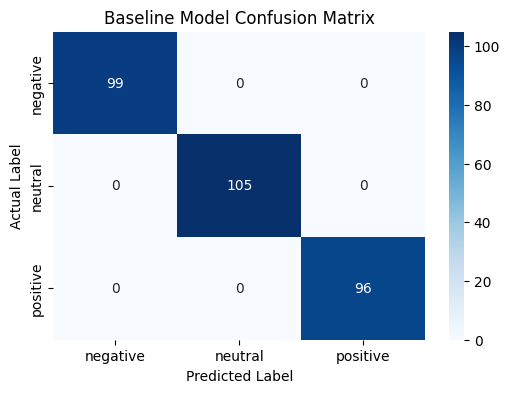

In [13]:
# Task 4: Baseline Model

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns


# Select text and target columns
X_text = df["customer_message"]
y = df["sentiment_label"]

# Split dataset into training and testing sets
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Convert text into TF-IDF vectors
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

# Build baseline model
baseline_model = LogisticRegression(
    max_iter=1000
)

# Train model
baseline_model.fit(X_train_tfidf, y_train)

# Make predictions
y_pred = baseline_model.predict(X_test_tfidf)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Baseline Model Accuracy:", round(accuracy * 100, 2), "%")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=baseline_model.classes_,
    yticklabels=baseline_model.classes_
)

plt.title("Baseline Model Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

A baseline text classification model was built using TF-IDF vectorization and Logistic Regression.

*   First, the customer messages were converted into numerical TF-IDF features because machine learning models cannot understand raw text directly.
*   The dataset was then split into training and testing sets using an 80:20 ratio.
*   Logistic Regression was trained on the TF-IDF features and evaluated on the test set.
*   The model performance was measured using accuracy, precision, recall, F1-score, and confusion matrix. List item

This baseline model gives a simple reference point for comparing more advanced models later.

In [15]:
# Task 5: Sequence Model or Conceptual Architecture

import pandas as pd
import re
import nltk

from nltk.corpus import stopwords
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

nltk.download("stopwords")

# Load dataset
df = pd.read_csv("customer_support_text_classification.csv")

# Clean text
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df["cleaned_message"] = df["customer_message"].apply(clean_text)

# Tokenization
max_words = 5000
max_length = 30

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(df["cleaned_message"])

sequences = tokenizer.texts_to_sequences(df["cleaned_message"])

# Padding
X = pad_sequences(
    sequences,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

# Encode target labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df["sentiment_label"])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1200, 30)
X_test shape: (300, 30)
y_train shape: (1200,)
y_test shape: (300,)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [16]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

vocab_size = 5000
num_classes = len(label_encoder.classes_)

model = Sequential()

model.add(Embedding(
    input_dim=vocab_size,
    output_dim=64,
    input_length=max_length
))

model.add(LSTM(64))

model.add(Dropout(0.5))

model.add(Dense(num_classes, activation="softmax"))

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [18]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print("Final Test Accuracy:", round(test_accuracy * 100, 2), "%")
print("Final Test Loss:", round(test_loss, 4))


Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 1.0000 - loss: 0.0126 - val_accuracy: 1.0000 - val_loss: 0.0042
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 1.0000 - loss: 0.0063 - val_accuracy: 1.0000 - val_loss: 0.0026
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 1.0000 - loss: 0.0053 - val_accuracy: 1.0000 - val_loss: 0.0019
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 0.0044 - val_accuracy: 1.0000 - val_loss: 0.0014
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 1.0000 - loss: 0.0036 - val_accuracy: 1.0000 - val_loss: 0.0011
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 1.0000 - loss: 0.0027 - val_accuracy: 1.0000 - val_loss: 9.3059e-04
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 0.0023 - val_accuracy: 1.0000 - val_loss: 7.8740e-04
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 1.0000 - loss: 0.0021 - val_accuracy: 1.

**Conceptual Architecture Design:**

LSTM Sequence Model

A simple LSTM-based sequence model was used for customer support text classification. The model classifies customer messages into three sentiment

classes: negative, neutral, and positive.

**Input Sequence**

Each customer message is first cleaned by converting it to lowercase and removing unnecessary symbols or special characters. After cleaning, the text is tokenized, which means each word is converted into a number. Since all messages may have different lengths, padding is applied so that every message has the same fixed length.

For example, a message such as “My refund is still pending and frustrating” may be cleaned and converted into a numerical sequence. This sequence becomes the input for the model.

**Embedding Layer**
The embedding layer converts each word number into a dense numerical vector. This helps the model understand the meaning and relationship between words instead of treating them as simple numbers. For example, words like refund, payment, delay, and pending may have related meanings in customer support messages.

**Recurrent / Sequence Layer**
The LSTM layer processes the message word by word. It remembers important information from earlier parts of the sentence and uses that context to understand the overall meaning of the message. This is useful because word order matters in text. For example, “refund was fast” may indicate positive sentiment, while “refund was delayed” may indicate negative sentiment.

**Output Layer**
The output layer is a dense layer with softmax activation. Since the dataset has three sentiment classes, the output layer has three neurons. Each neuron gives the probability of one class: negative, neutral, or positive. The class with the highest probability is selected as the final prediction.

**Loss Function**
The suitable loss function is sparse categorical cross-entropy. It is used because this is a multi-class classification problem and the sentiment labels are encoded as numbers.

**Final Flow**
Customer message → Text cleaning → Tokenization → Padding → Input sequence → Embedding layer → LSTM layer → Dense output layer → Softmax prediction → Final sentiment class.

**Task 6: Attention and Transformer Reflection**

**Why RNNs Struggle with Long-Term Dependencies**
RNNs process text one word at a time in sequence. Because of this, they may forget important information from earlier words when the sentence is long. This makes it difficult for a basic RNN to understand long-term relationships in text.

For example, in a long customer complaint, the main issue may be mentioned at the beginning, but the sentiment may appear much later. A simple RNN may not remember the earlier information clearly.

**How LSTMs Help with Memory**
LSTMs are an improved version of RNNs. They have a special memory mechanism that helps them remember important information for a longer time.

LSTMs decide:
What information to keep?
What information to forget?
What new information to add?

Because of this, LSTMs are better at understanding longer text sequences compared to basic RNNs.

**What Attention Solves in Sequence-to-Sequence Tasks**
Attention helps the model focus on the most important words in the input sequence while generating or predicting output.
Instead of treating all words equally, attention gives more importance to relevant words.

For example, in a customer support message, words like:
refund
delay
frustrating
helpful
resolved

may be more important for sentiment classification.
Attention helps the model focus on such important words and improves understanding.

**Why Transformers Are Important in Modern NLP and Generative AI**
Transformers are important because they use attention instead of processing text strictly word by word like RNNs.

This allows transformers to:
Understand relationships between words more effectively
Handle long text better
Train faster using parallel processing
Perform well on tasks like classification, translation, summarization, question answering, and text generation

Modern Generative AI models are based on transformer architecture because transformers can understand context, generate human-like text, and work with large amounts of language data effectively.